In [25]:
import torch 
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [26]:
X_np,y_np = datasets.make_regression(n_samples=100,n_features=1,noise=20,random_state=42)

print(X_np.shape, y_np.shape)

(100, 1) (100,)


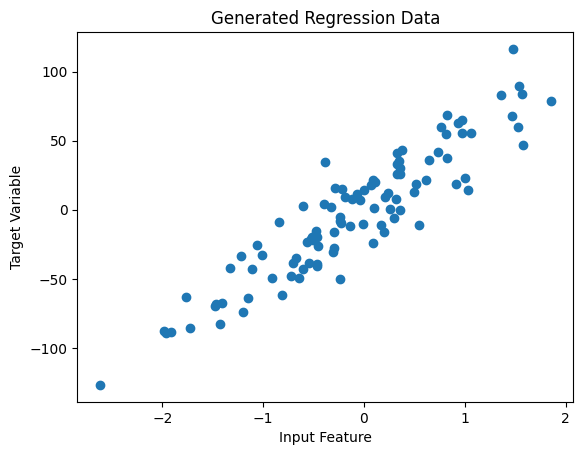

In [27]:
plt.plot(X_np, y_np, 'o')
plt.xlabel('Input Feature')
plt.ylabel('Target Variable')
plt.title('Generated Regression Data')
plt.show()

In [28]:
X_tensor = torch.from_numpy(X_np.astype(np.float32))
y_tensor = torch.from_numpy(y_np.astype(np.float32))

In [29]:
type(X_tensor), type(y_tensor)
X_tensor.dtype, y_tensor.dtype

(torch.float32, torch.float32)

In [30]:
class LinearReg(torch.nn.Module):
  def __init__(self, in_features,out_features):
    super().__init__() 
    self.linear = nn.Linear(in_features,out_features)

  def forward(self, x):
    return self.linear(x)

  def criterion(self, yhat, y):
    return nn.MSELoss()(yhat,y)


In [31]:
y_tensor.shape

torch.Size([100])

In [32]:
num_epochs = 10000
model = LinearReg(1,1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
y_pred = model(X_tensor)
print(f'Predicted shape: {y_pred.shape}, Actual shape : {y_tensor.shape}')

Predicted shape: torch.Size([100, 1]), Actual shape : torch.Size([100])


In [33]:
print(y_pred[:5])
y_pred = y_pred.flatten()
print(y_pred[:5])

tensor([[ 0.2215],
        [ 0.0240],
        [-0.2439],
        [ 0.0771],
        [-0.1085]], grad_fn=<SliceBackward0>)
tensor([ 0.2215,  0.0240, -0.2439,  0.0771, -0.1085], grad_fn=<SliceBackward0>)


In [34]:
for epoch in range(num_epochs):

    model.train()

    optimizer.zero_grad()

    y_pred = model(X_tensor)
    y_pred = y_pred.flatten()

    loss = model.criterion(y_pred, y_tensor)

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')

Epoch: 0, Loss: 2114.66064453125
Epoch: 10, Loss: 2106.4619140625
Epoch: 20, Loss: 2098.310546875
Epoch: 30, Loss: 2090.211669921875
Epoch: 40, Loss: 2082.16748046875
Epoch: 50, Loss: 2074.179443359375
Epoch: 60, Loss: 2066.246826171875
Epoch: 70, Loss: 2058.368408203125
Epoch: 80, Loss: 2050.543701171875
Epoch: 90, Loss: 2042.7711181640625
Epoch: 100, Loss: 2035.0487060546875
Epoch: 110, Loss: 2027.375732421875
Epoch: 120, Loss: 2019.75
Epoch: 130, Loss: 2012.1707763671875
Epoch: 140, Loss: 2004.63623046875
Epoch: 150, Loss: 1997.1448974609375
Epoch: 160, Loss: 1989.6954345703125
Epoch: 170, Loss: 1982.28662109375
Epoch: 180, Loss: 1974.9168701171875
Epoch: 190, Loss: 1967.585205078125
Epoch: 200, Loss: 1960.2901611328125
Epoch: 210, Loss: 1953.0306396484375
Epoch: 220, Loss: 1945.8052978515625
Epoch: 230, Loss: 1938.61328125
Epoch: 240, Loss: 1931.4532470703125
Epoch: 250, Loss: 1924.3245849609375
Epoch: 260, Loss: 1917.22607421875
Epoch: 270, Loss: 1910.1568603515625
Epoch: 280, Los

In [35]:
predicted = model(X_tensor)
y_pred = predicted.detach().numpy()

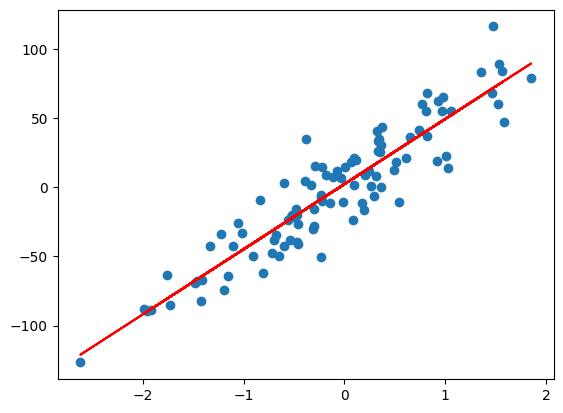

In [36]:
predicted = model(X_tensor)
y_pred = predicted.detach().numpy()

plt.plot(X_np, y_np, 'o', label='Original Data')
plt.plot(X_np, y_pred, 'r-', label='Fitted Line')